# Appearance of the reconstructed held-out images (axis-200-900)

How the reconstructed images look, channel by channel: every peak m/z of a held-out image is compared as an image between the input and the reconstruction, and the best, median and worst channels are shown with their m/z and an error image. Annotated ions are compared additionally with the METASPACE reference. The error analysis of the same images (Masserstein) is in `part_1_04`.

## Introduction

A channel is the apex bin of a peak of the image's mean input spectrum. Its input image $X_j(x)$ and
reconstructed image $\hat X_j(x)$ are compared over the pixels of the image by the Pearson correlation
(shape of the image, independent of a global scale) and by the relative L1 error
$\sum_x |\hat X_j - X_j| / \sum_x X_j$ (intensity); the intensity ratio $\sum_x \hat X_j / \sum_x X_j$ shows a
global loss or gain. Inputs and reconstructions are TIC-normalized, as seen by the model.
For an annotated ion with m/z $m_i$ the ion image is $I_i(x) = \sum_{j \in B_i} X_j(x)$ over the bin containing
$m_i$ and one neighbouring bin on either side; METASPACE ion images are extracted by METASPACE from the raw
profile data at the annotated m/z and serve as an independent reference.

### Assumptions

* `test` pixels come from training images and are spatially correlated with training pixels; `heldout_image`
  pixels come from three images never seen during training. Generalization to new images is therefore judged on
  `heldout_image`, generalization to new pixels on `test`.
* Repetitions differ only in initialization and training seed; they share the split. Five repetitions per axis
  are the experimental units for model-level statements; pixels are not independent units.

        * Channels: peaks of the image's mean spectrum at least $10^{-3}$ of the base peak, apexes at least 3 bins apart,
          displayed windows only (`image_channels` settings).
        * Images show the representative model of the axis (next section). Channel statistics are computed for this
          model; ion agreement statistics for every repetition.
        * METASPACE images are intensities, not presence masks. The annotation target of a pixel is
          `METASPACE intensity > 0`: a weak but non-zero pixel is as positive as a strong one.
        * Repeated rows of the METASPACE export (one per database, identical images) are dropped when the populations
          are decoded.

### Notation

* $X \in \mathbb{R}_{\ge 0}^{M}$: TIC-normalized input spectrum on the axis ($M$ bins of 0.55 Da);
  $\hat X = \mathrm{Dec}(\mathrm{Enc}(X))$: its reconstruction (TIC-normalized decoder output).
* $Z = \mathrm{Enc}(X) \in \mathbb{R}^{10}$: latent code; $U$: canonicalized code (bottleneck LayerNorm affine
  removed; rows lie on a sphere of radius $\sqrt{10}$ with zero row sum).
* $\hat Y = \sigma(h(Z)) \in [0, 1]^{C}$: head probabilities of the $C$ train-observed molecule classes.
* $P \in \{\mathrm{train}, \mathrm{test}, \mathrm{test\_extended}, \mathrm{heldout\_image}\}$: pixel population;
  $r = 0, \dots, 4$: repetition (independent training seed of the same configuration).
* $W_1(X, \hat X)$: training Masserstein cost, the exact one-dimensional Wasserstein-1 distance between the
  TIC-normalized spectra, in m/z units.
* Window $W = [a, a + 100)$ m/z, aligned to multiples of 100 on every axis.

        * $r_j$: Pearson correlation of the input and reconstructed image of channel $j$ over the pixels of one image.
        * $I_i$, $\hat I_i$, $I_i^{\mathrm{MS}}$: input, reconstructed and METASPACE ion image of ion $i$;
          $\rho_s(\cdot, \cdot)$: Spearman correlation over the pixels of the ion's image.

## Configuration

In [1]:
import logging
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

# Library modules log INFO to stdout; warnings stay visible, progress messages do not.
logging.disable(logging.INFO)
current_path = Path.cwd().resolve()
repository_root = next(path for path in (current_path, *current_path.parents) if (path / "pyproject.toml").is_file())
os.chdir(repository_root)

from msi_autoencoder_wrapper.analysis.autoencoder.experiments import pretraining_campaign as campaign
from msi_autoencoder_wrapper.analysis.autoencoder.experiments.pretraining_campaign_precompute import (
    load_metadata, load_table, run_command,
)
from msi_autoencoder_wrapper.analysis.precompute.notebook_inputs import load_model_catalog, load_visualization_theme
from msi_autoencoder_wrapper.visualization import pretraining as figures

SETTINGS_PATH = Path("assets/experiments/autoencoder_architecture/notebooks/segmentation_model/20_09_metaspace_pretrain/analysis_settings.yaml")
ANALYSIS = "reconstructed_ion_images"
AXIS = "axis-200-900"

settings = campaign.load_settings(SETTINGS_PATH)
theme = load_visualization_theme(settings).with_overrides(figure_dpi=100)
catalog = load_model_catalog(settings)
metadata = load_metadata(settings, ANALYSIS, AXIS)
pd.set_option("display.precision", 4)
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_rows", 80)


def table(name: str) -> pd.DataFrame:
    """Load one canonical table written for this notebook by the precompute."""
    return load_table(settings, ANALYSIS, name, AXIS)


def mean_sd(frame: pd.DataFrame, keys: list, columns: list) -> pd.DataFrame:
    """Mean and SD over repetitions of the given columns (presentation helper)."""
    long = frame.melt(id_vars=keys, value_vars=columns, var_name="quantity", value_name="value")
    return long.groupby([*keys, "quantity"]).value.agg(["mean", "std"]).unstack("quantity")


LABELS = list(catalog.drop_duplicates("display_label").sort_values("display_order").display_label)
LABEL_COLORS = {label: figures.model_color(label, theme, position) for position, label in enumerate(LABELS)}
POPULATION_COLORS = {name: figures.population_color(name, theme) for name in figures.POPULATION_ORDER}
CLASS_SET_COLORS = {name: figures.class_set_color(name, theme) for name in figures.CLASS_SET_ORDER}
print("Analysis:", ANALYSIS, "| axis:", AXIS, "| models:", len(metadata["models"]))
print("Cache keys:", metadata["cache_keys"])

POPULATIONS = ['train', 'test', 'test_extended', 'heldout_image']
AXIS_LABEL = settings['axes'][AXIS]['label']
MODEL_LABEL = catalog[catalog.axis == AXIS].display_label.iloc[0]
DATASETS = sorted(load_table(settings, 'heldout_image_reconstruction', 'image_metrics', AXIS).dataset_id.unique())
print('Axis label:', AXIS_LABEL, '| held-out images:', DATASETS)

channels = table('channel_metrics')
selection = table('channel_selection')
channel_pixels = table('channel_pixels')
agreement = table('ion_agreement')
ion_pixels = table('ion_pixels')
print('Representative model:', metadata['representative_model'], '| criterion:', metadata['criterion'])

Analysis: reconstructed_ion_images | axis: axis-200-900 | models: 5
Cache keys: {'plan': 'f34a92a8f6f7833f', 'populations': '513690bdd78a83ce', 'inference': '0243c1efb93b9c4c'}
Axis label: 200-900 m/z | held-out images: ['2024-02-20_01h45m20s', '2024-02-20_01h46m58s', '2024-02-20_01h54m41s']


Representative model: metaspace-pretrain-repaired-20260923-01__grid_0000__rep_02__real_only | criterion: pearson


## Producing the tables this notebook reads

### Methodology

#### Implementation

Channels are detected on the decoded held-out inputs; the reconstruction of the representative model on the
displayed bins is stored by the `inference` level. Input ion images are computed at the population level,
reconstructed ion images in the `inference` level (every model); `reconstructed_ion_images` computes all
statistics and exports the pixel values of the selected channels and of every annotated ion.

The command below is generated by the precompute entry point itself; if a table is missing, `load_table` raises with the same command.

In [2]:
print(run_command(settings, ANALYSIS))

nohup uv run --extra cu118 python -m msi_autoencoder_wrapper.analysis.precompute --settings /home/max/repositories/MSIAutoEncoderWrapper/assets/experiments/autoencoder_architecture/notebooks/segmentation_model/20_09_metaspace_pretrain/analysis_settings.yaml --analysis reconstructed_ion_images > /home/max/repositories/MSIAutoEncoderWrapper/assets/experiments/autoencoder_architecture/notebooks/segmentation_model/20_09_metaspace_pretrain/shared_precompute.log 2>&1 &


### Remarks

### Notes

## Representative model shown in the images

### Methodology

#### Theoretical

Images are never averaged over repetitions, because averaging blurs them. Every image shows the
representative model of its axis: the repetition with the lowest mean rank over five metrics on the withheld
test pixels, Masserstein $W_1$ and spectral angle (lower is better), macro AP, micro AP and macro F1 at 0.5
(higher is better; annotation retrieval, classes observed in training); equal mean ranks are decided by macro
AP. The held-out images are not used for the choice, so the displayed model is not selected on the images it
is shown on.

#### Implementation

`representative_model` holds, per model and metric, the test value, its rank among the repetitions of the axis, the mean rank and the flag.

#### Figure descriptions

No figure; one row per model with the metric values, the mean rank and the representative flag.

In [3]:
ranking = table('representative_model')
values = ranking.pivot_table(index=['axis', 'repetition', 'model_id'], columns='metric', values='value')
flags = ranking.groupby(['axis', 'repetition', 'model_id']).agg(mean_rank=('mean_rank', 'first'), representative=('representative', 'first'))
display(values.join(flags).round(4))

average_precision      f1  masserstein  micro_average_precision  spectral_angle  mean_rank  representative
axis         repetition model_id                                                                                                                                                      
axis-200-900 0          metaspace-pretrain-repaired-20260923-01__grid_0...             0.6970  0.4851       3.2834                   0.8835          0.9449        3.0           False
             1          metaspace-pretrain-repaired-20260923-01__grid_0...             0.6899  0.4772       2.9758                   0.8751          1.0732        4.2           False
             2          metaspace-pretrain-repaired-20260923-01__grid_0...             0.6990  0.5055       3.1069                   0.8918          0.9337        1.4            True
             3          metaspace-pretrain-repaired-20260923-01__grid_0...             0.6947  0.4789       3.1123                   0.9003          0.9509        3.2           False
             4          metaspace-pretrain-repaired-20260923-01__grid_0...             0.6957  0.4872       3.1081                   0.8833          0.9554        3.2           False

### Remarks

- Representative model: repetition 2 (mean rank 1.4 of 5): best macro AP (0.699), F1 (0.506) and spectral angle (0.934); repetition 1 has the lowest $W_1$ (2.98) but the worst angle and AP, so no repetition wins every metric.

### Notes

## Channel image agreement along m/z

### Methodology

#### Theoretical

$r_j$ against the channel m/z shows in which m/z regions the reconstructed images keep their shape and where
they fail; the relative L1 error adds the intensity view.

#### Implementation

`channel_metrics` holds one row per image and channel (representative model).

#### Figure descriptions

Left: x = channel m/z, y = Pearson correlation; right: x = channel m/z, y = relative L1 error (log); colour =
held-out image. The table gives per image the number of channels, the median correlation, the fraction of
channels with $r_j \ge 0.9$ and the median relative L1 error.

,channels,median_pearson,fraction_above_0_9,median_relative_l1,median_intensity_ratio
dataset_id,,,,,
2024-02-20_01h45m20s,185,0.3616,0.1027,0.9268,0.3420
2024-02-20_01h46m58s,176,0.4759,0.1420,0.9305,0.3155
2024-02-20_01h54m41s,176,0.3775,0.0966,0.9006,0.3182


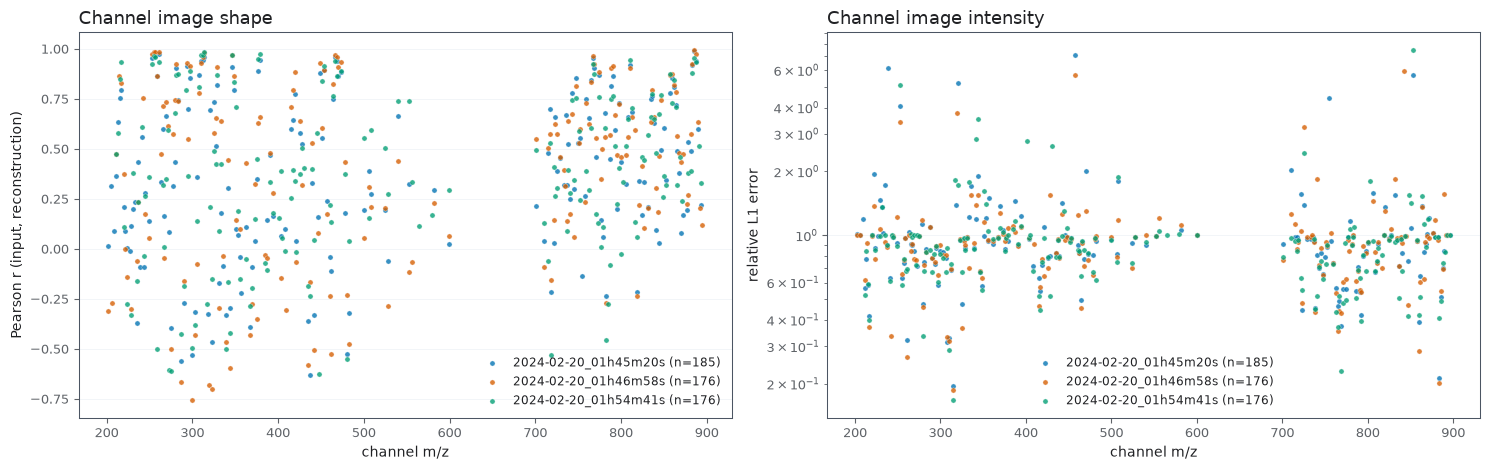

In [4]:
image_colors = {dataset: theme.model_palette[position % len(theme.model_palette)] for position, dataset in enumerate(DATASETS)}
figure, axes = plt.subplots(1, 2, figsize=(15, 4.8), dpi=theme.figure_dpi)
figures.paired_scatter(channels, x='mz', y='pearson', hue='dataset_id', hue_order=DATASETS, colors=image_colors, xlabel='channel m/z', ylabel='Pearson r (input, reconstruction)', title='Channel image shape', diagonal=False, ax=axes[0], theme=theme)
figures.paired_scatter(channels, x='mz', y='relative_l1', hue='dataset_id', hue_order=DATASETS, colors=image_colors, xlabel='channel m/z', ylabel='relative L1 error', title='Channel image intensity', diagonal=False, ax=axes[1], theme=theme)
axes[1].set_yscale('log')
figure.tight_layout()
display(channels.groupby('dataset_id').agg(channels=('pearson', 'size'), median_pearson=('pearson', 'median'), fraction_above_0_9=('pearson', lambda values: float((values >= 0.9).mean())), median_relative_l1=('relative_l1', 'median'), median_intensity_ratio=('intensity_ratio', 'median')))

### Remarks

- 176-185 peak channels per image. Median $r_j$ 0.36-0.48; only 10-14 % of the channels reach $r_j \ge 0.9$ and 17-23 % are negatively correlated.
- Channel intensity is lost: median relative L1 0.90-0.93 and median intensity ratio 0.32-0.34 (the apex bin keeps a third of its intensity, consistent with the widened peaks of `part_1_03`).
- Shape depends on peak height: $r_j$ 0.91 for peaks above 10 % of the base peak (46 channels), 0.56 for 1-10 %, 0.22 below 1 %. Along m/z, 700-900 is best (median 0.48-0.53), 300-400 and 500-600 worst (0.19, 0.25).

### Notes

## Best, median and worst reconstructed channel images

### Methodology

#### Theoretical

For every held-out image the two channels with the highest, the two around the median and the two with the
lowest $r_j$ are shown as images, so that a correlation value can be judged visually and the failing m/z can be
read off directly.

#### Implementation

`channel_selection` and `channel_pixels` (representative model).

#### Figure descriptions

One figure per held-out image; rows = selected channels (kind, rank, m/z, $r_j$, relative L1), columns = input
image and reconstructed image, each with its own colour range (1st-99th percentile), so that the shape of a
weaker reconstruction stays visible, and the error image reconstruction - input (symmetric range), which shows
the intensity difference.

,dataset_id,kind,rank,mz,pearson,relative_l1,intensity_ratio,channels
0,2024-02-20_01h45m20s,best,0,885.5789,0.9900,0.5145,0.4877,184
1,2024-02-20_01h45m20s,best,1,260.7753,0.9767,0.3231,1.1513,184
2,2024-02-20_01h45m20s,median,0,211.2751,0.3640,0.5676,0.6071,184
3,2024-02-20_01h45m20s,median,1,305.8756,0.3592,0.7794,0.2693,184
4,2024-02-20_01h45m20s,worst,0,437.3263,-0.6298,0.9552,0.0481,184
5,2024-02-20_01h45m20s,worst,1,287.1755,-0.5583,1.0972,1.0451,184
6,2024-02-20_01h46m58s,best,0,885.5789,0.9953,0.5480,0.4547,176
7,2024-02-20_01h46m58s,best,1,254.7253,0.9850,0.6604,0.3562,176
8,2024-02-20_01h46m58s,median,0,262.9753,0.4760,1.0082,0.1661,176
9,2024-02-20_01h46m58s,median,1,871.8287,0.4759,0.9710,0.1086,176


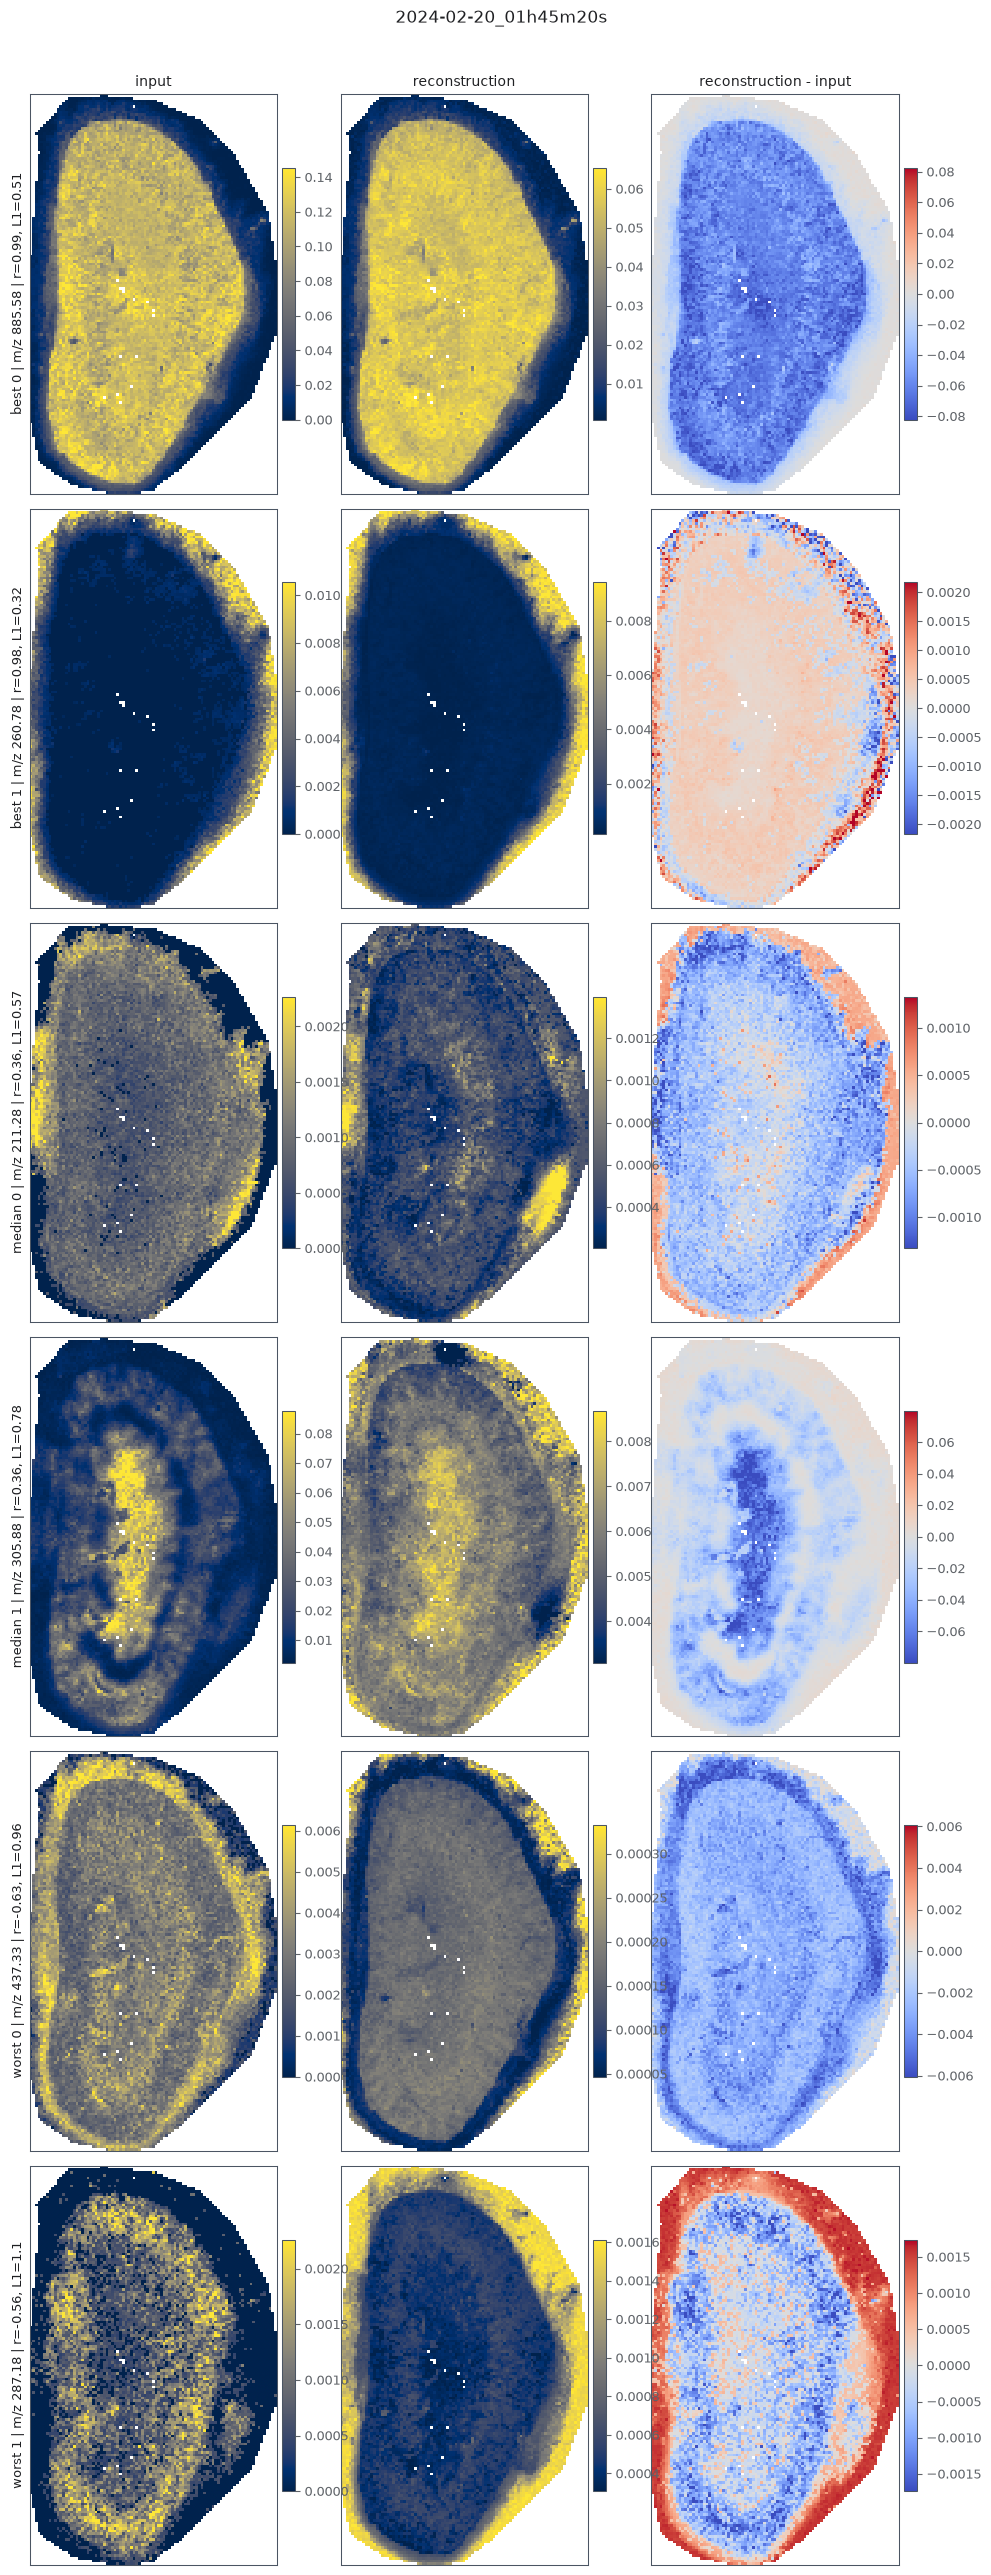

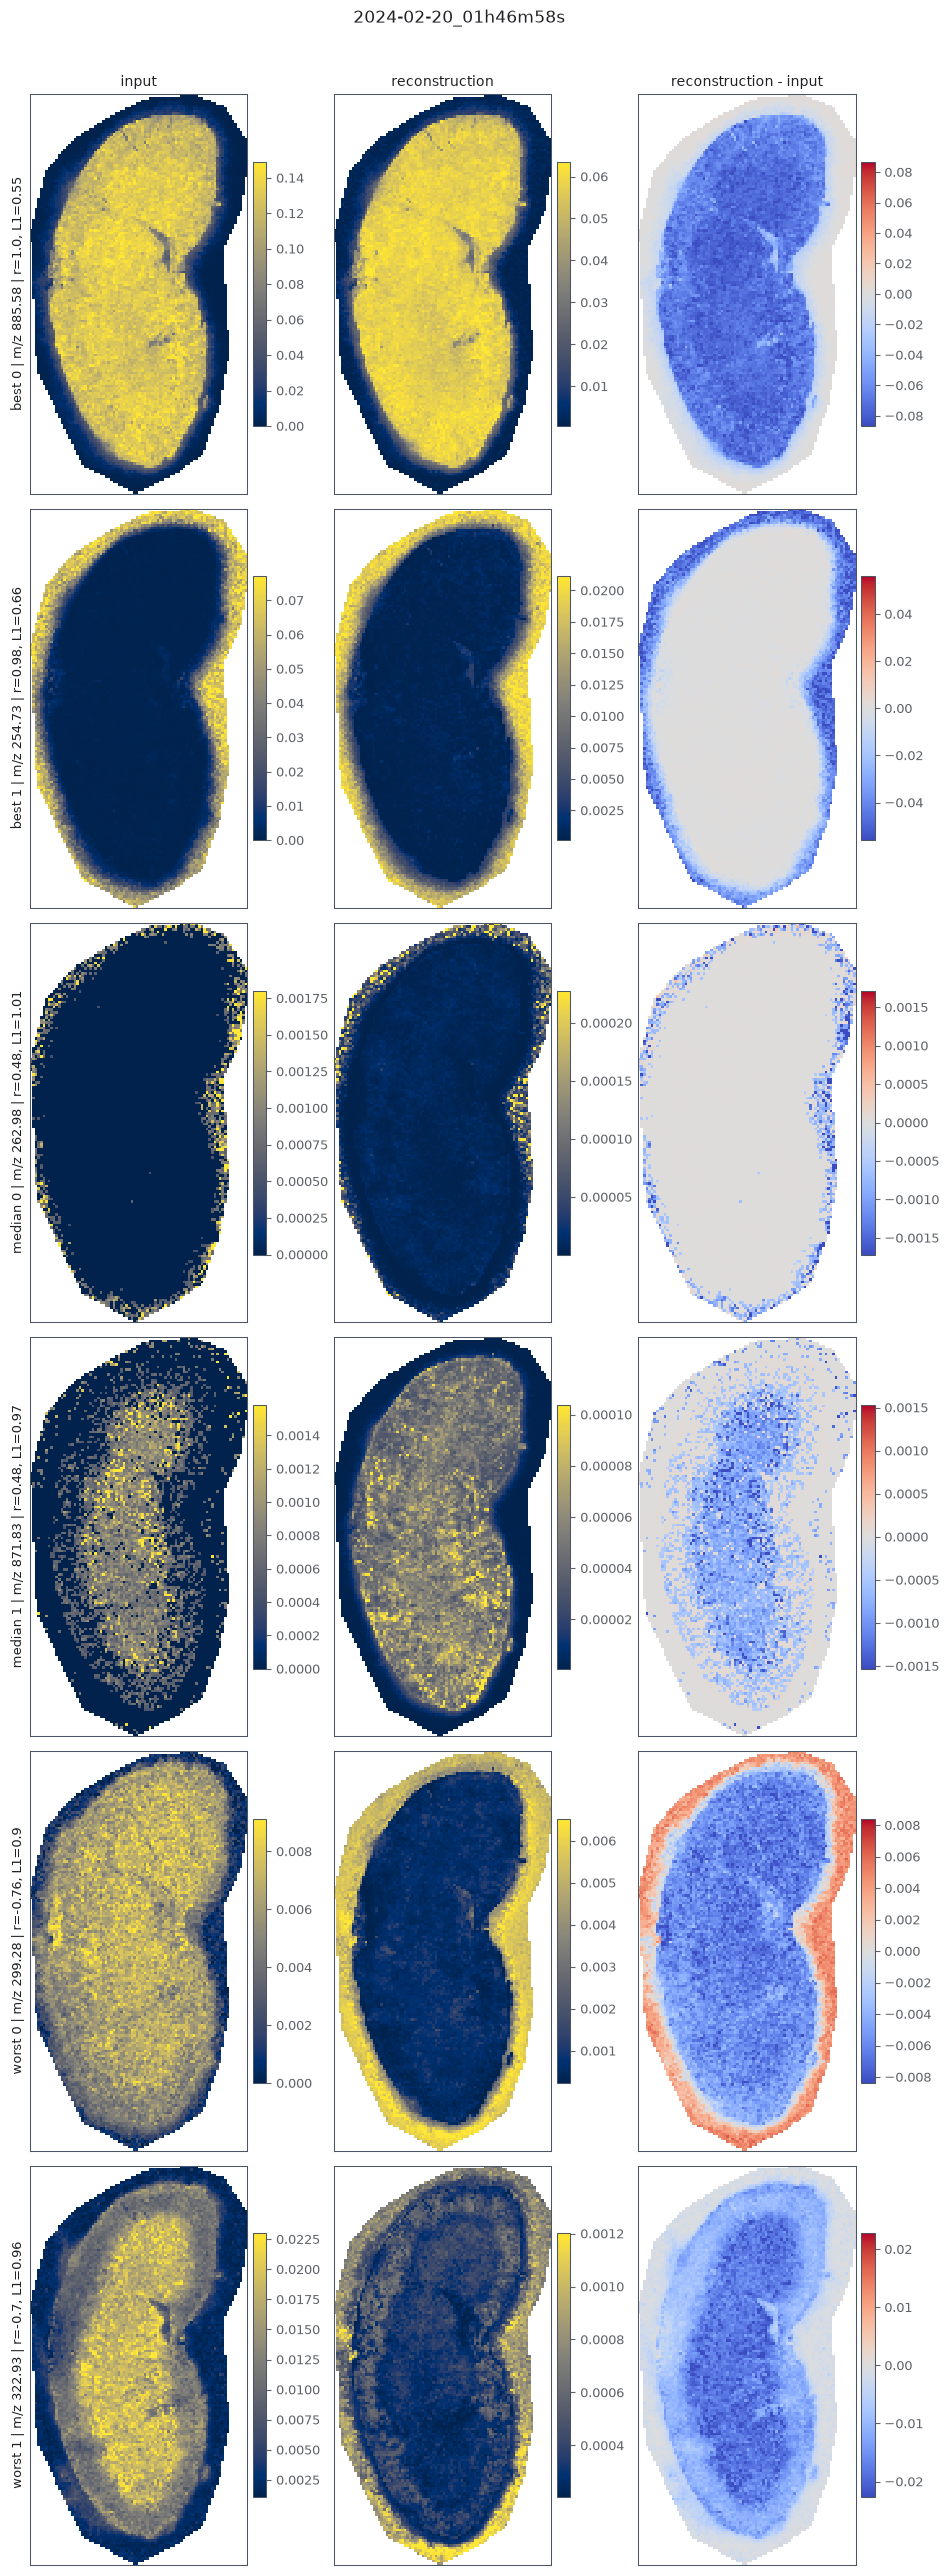

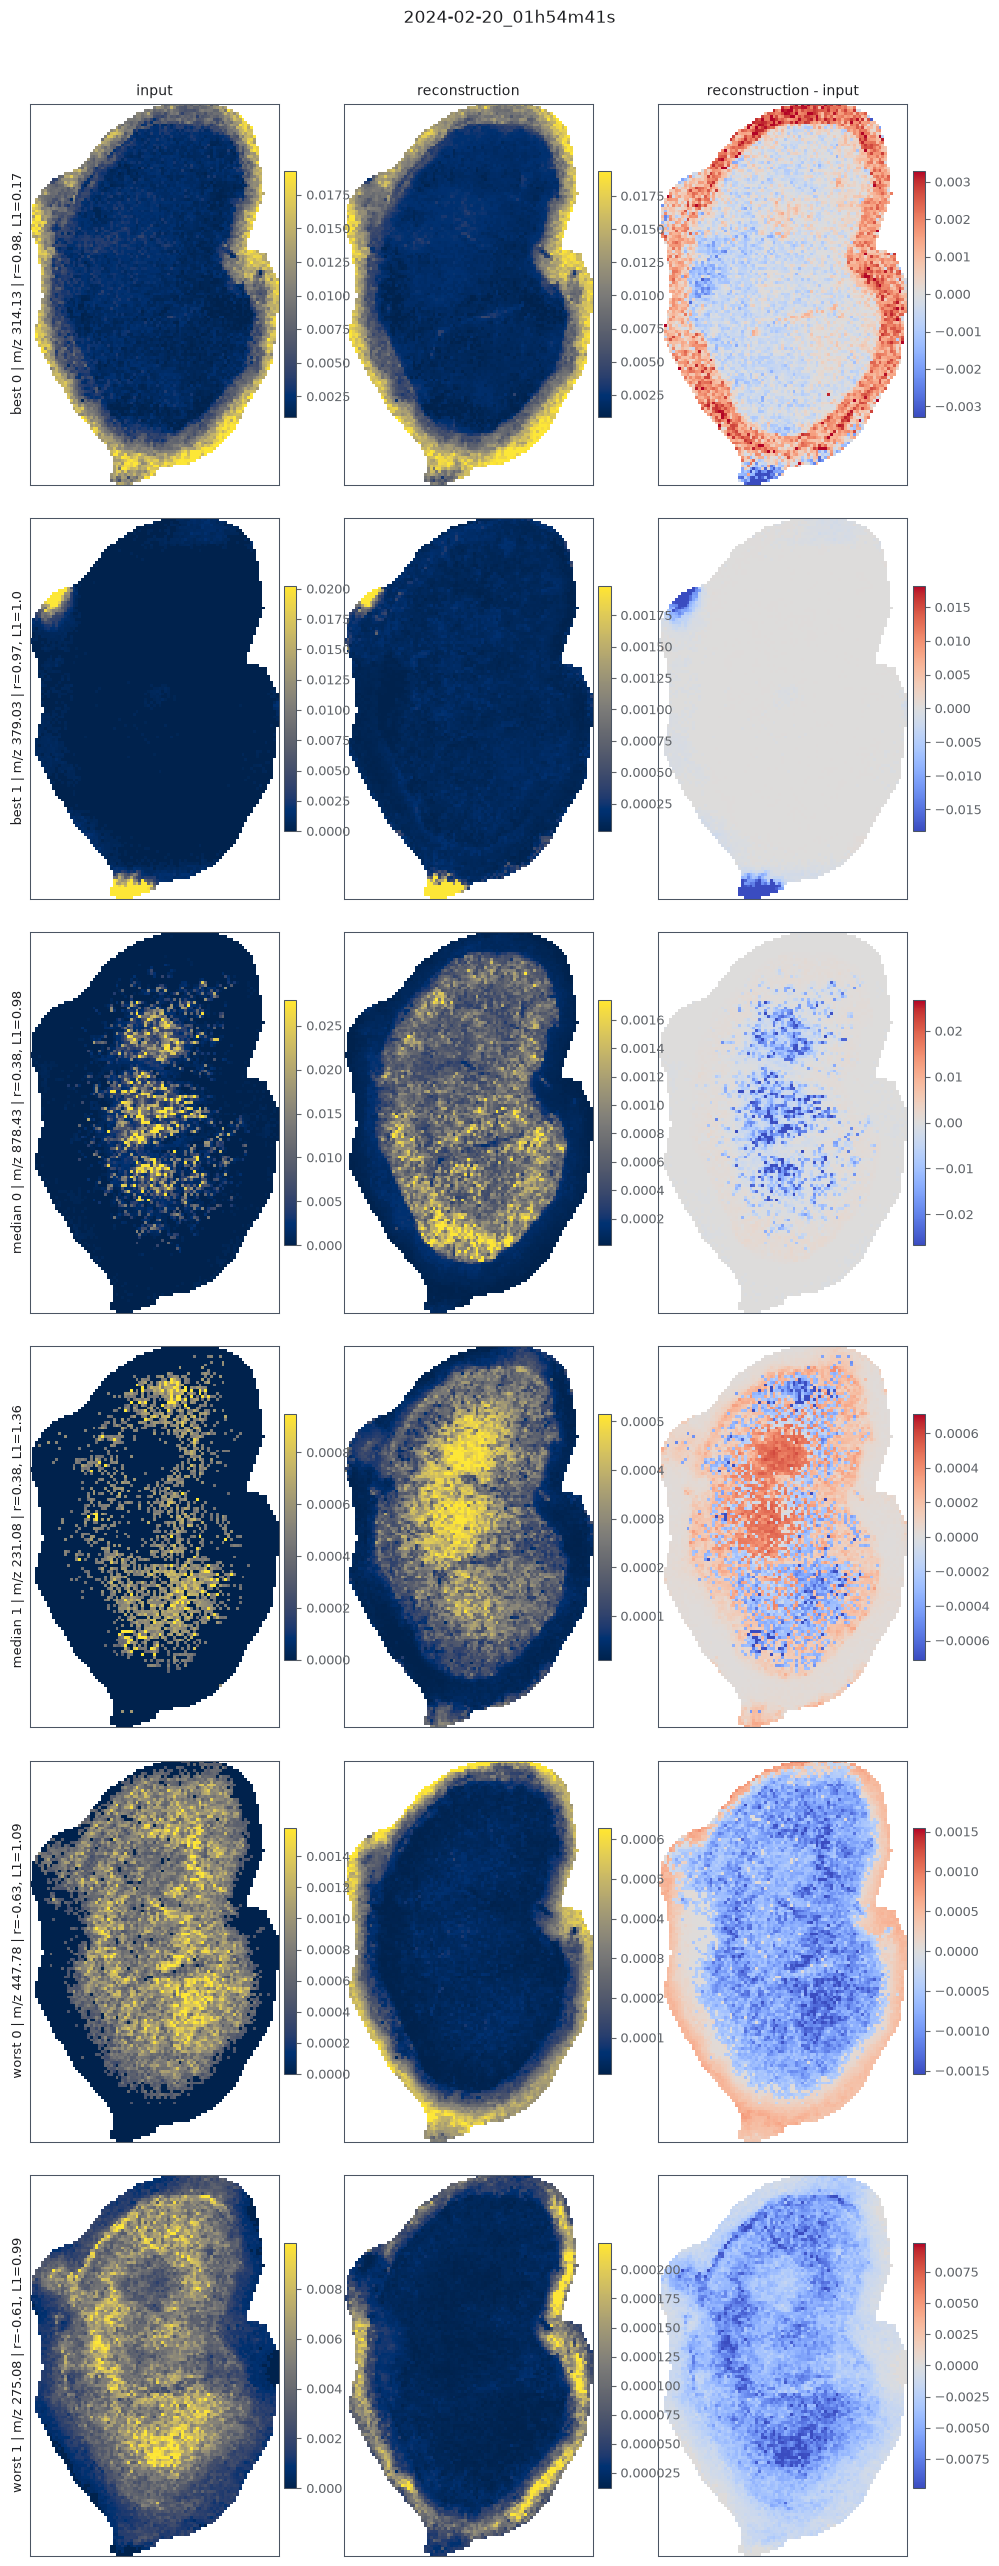

In [5]:
display(selection[['dataset_id', 'kind', 'rank', 'mz', 'pearson', 'relative_l1', 'intensity_ratio', 'channels']])
for dataset in DATASETS:
    frame = channel_pixels[channel_pixels.dataset_id == dataset].merge(selection[selection.dataset_id == dataset][['kind', 'rank', 'pearson', 'relative_l1']], on=['kind', 'rank'])
    frame['panel'] = frame.kind + ' ' + frame['rank'].astype(str) + ' | m/z ' + frame.mz.round(2).astype(str) + ' | r=' + frame.pearson.round(2).astype(str) + ', L1=' + frame.relative_l1.round(2).astype(str)
    order = {'best': 0, 'median': 1, 'worst': 2}
    rows = list(dict.fromkeys(frame.assign(order=frame.kind.map(order)).sort_values(['order', 'rank']).panel))
    figures.image_panels(frame, value_columns=['input', 'output', 'error'], column_titles=['input', 'reconstruction', 'reconstruction - input'], datasets=rows, row_column='panel', shared_scale='panel', diverging_columns=['error'], cmap=theme.image_colormap, theme=theme)
    plt.suptitle(dataset, y=1.02)
    plt.show()

### Remarks

- Best channels (r 0.97-0.995): 885.58 (strong peak, two images), 254.7-260.8, 314.1, 379.0 m/z; the reconstructed image has the right shape but about half the intensity.
- Worst channels (r -0.56 to -0.76): 275-322 and 437-448 m/z. The input image is bright at the tissue border while the reconstruction is dark there and slightly brighter inside.
- Hypothesis for the negative correlations: at these bins the reconstruction follows the widened envelope of a neighbouring stronger peak with a different spatial distribution; not tested here.

### Notes

## Annotated ions: agreement of input, reconstruction and METASPACE

### Methodology

#### Theoretical

Three correlations per ion and repetition: $\rho_s(I_i, \hat I_i)$ (does the reconstruction keep the ion's
spatial pattern), $\rho_s(I^{\mathrm{MS}}_i, I_i)$ (how well binning reproduces METASPACE) and
$\rho_s(I^{\mathrm{MS}}_i, \hat I_i)$ (the reconstruction against the reference).

#### Implementation

`ion_agreement` holds one row per model and ion; the table gives per-image medians over ions.

#### Figure descriptions

x = held-out image, y = Spearman correlation per ion; colour = compared pair; one point per ion and repetition,
bar = mean. Values near 1 mean identical spatial ranking.

,input_output_spearman,metaspace_input_spearman,metaspace_output_spearman,intensity_ratio
dataset_id,,,,
2024-02-20_01h45m20s,0.7026,0.5006,0.3068,0.7908
2024-02-20_01h46m58s,0.7327,0.6630,0.2940,0.7609
2024-02-20_01h54m41s,0.5493,0.4092,0.3725,0.9231


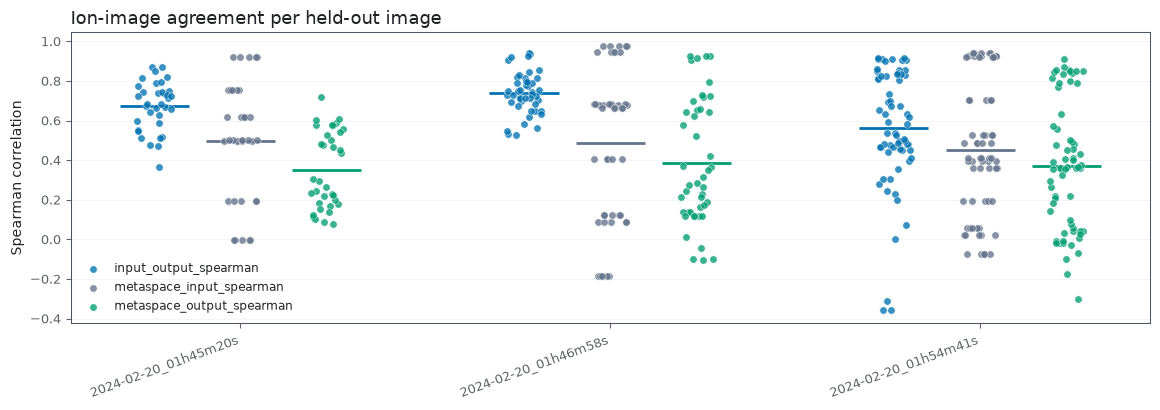

In [6]:
display(table('image_fidelity').groupby('dataset_id')[['input_output_spearman', 'metaspace_input_spearman', 'metaspace_output_spearman', 'intensity_ratio']].mean())
long = agreement.melt(id_vars=['dataset_id', 'repetition', 'class_name'], value_vars=['input_output_spearman', 'metaspace_input_spearman', 'metaspace_output_spearman'], var_name='pair', value_name='spearman')
figures.repetition_points(long, value='spearman', group='dataset_id', hue='pair', order=DATASETS, hue_order=['input_output_spearman', 'metaspace_input_spearman', 'metaspace_output_spearman'], colors={'input_output_spearman': theme.model_palette[0], 'metaspace_input_spearman': theme.input_color, 'metaspace_output_spearman': theme.model_palette[2]}, ylabel='Spearman correlation', title='Ion-image agreement per held-out image', theme=theme);

### Remarks

- 29 annotated ions (repeated METASPACE rows removed). Median $\rho_s$(input, reconstruction) 0.58-0.73; $\rho_s$(METASPACE, input) 0.41-0.66; $\rho_s$(METASPACE, reconstruction) 0.28-0.36.

### Notes

## Annotated ions: intensity preservation along m/z

### Methodology

#### Theoretical

The ratio $\sum \hat I_i / \sum I_i$ shows whether the reconstruction systematically loses or inflates an
ion; plotting it against $m_i$ shows whether this depends on the m/z region.

#### Implementation

Repetition means of the intensity ratio and of the agreement per ion.

#### Figure descriptions

Left: x = ion m/z, y = intensity ratio (log scale; 1 = preserved), colour = class set. Right: x =
$\rho_s(I^{\mathrm{MS}}, I)$, y = $\rho_s(I^{\mathrm{MS}}, \hat I)$; the diagonal marks equal agreement,
points below it lose agreement through reconstruction.

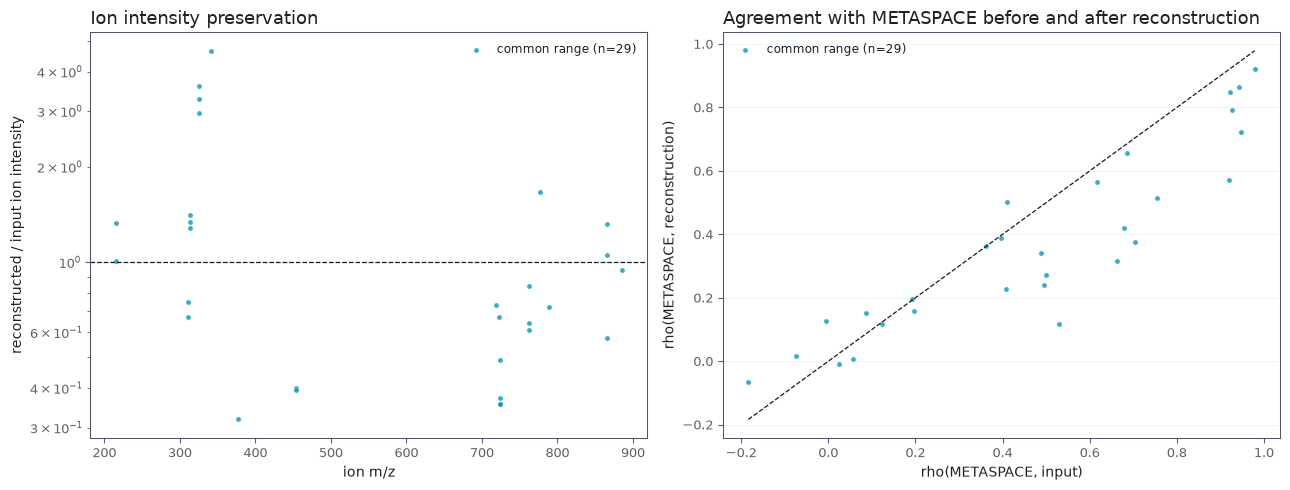

In [7]:
ions = agreement.groupby(['ion_index', 'dataset_id', 'class_name', 'mz', 'class_set'], as_index=False)[['intensity_ratio', 'input_output_spearman', 'metaspace_input_spearman', 'metaspace_output_spearman']].mean()
sets = [value for value in figures.CLASS_SET_ORDER if value in set(ions.class_set)]
figure, axes = plt.subplots(1, 2, figsize=(13, 5), dpi=theme.figure_dpi)
figures.paired_scatter(ions, x='mz', y='intensity_ratio', hue='class_set', hue_order=sets, xlabel='ion m/z', ylabel='reconstructed / input ion intensity', title='Ion intensity preservation', diagonal=False, ax=axes[0], theme=theme)
axes[0].set_yscale('log')
axes[0].axhline(1, color=theme.baseline_color, linestyle='--', linewidth=theme.reference_line_width)
figures.paired_scatter(ions, x='metaspace_input_spearman', y='metaspace_output_spearman', hue='class_set', hue_order=sets, xlabel='rho(METASPACE, input)', ylabel='rho(METASPACE, reconstruction)', title='Agreement with METASPACE before and after reconstruction', ax=axes[1], theme=theme)
figure.tight_layout()

### Remarks

- Median ion intensity ratio 0.76-0.90: summed over three bins, the ion image loses less than the single apex channel, because the widened peak stays mostly within the ion's bins.

### Notes

## Annotated ions: best and worst preserved ions per image

### Methodology

#### Theoretical

For every image the two ions with the highest and the two with the lowest $\rho_s(I_i, \hat I_i)$ of the
representative model are shown next to METASPACE and the annotation target.

#### Implementation

`ion_pixels` holds METASPACE intensity, annotation target, input and representative-model reconstruction per pixel.

#### Figure descriptions

Rows = image and ion (m/z, $\rho_s$), columns = METASPACE intensity (colour range from its positive pixels, so
sparse ions stay visible), annotation target (METASPACE > 0), input ion, reconstructed ion (each with its own
range, so that the shape of a weaker reconstruction stays visible).

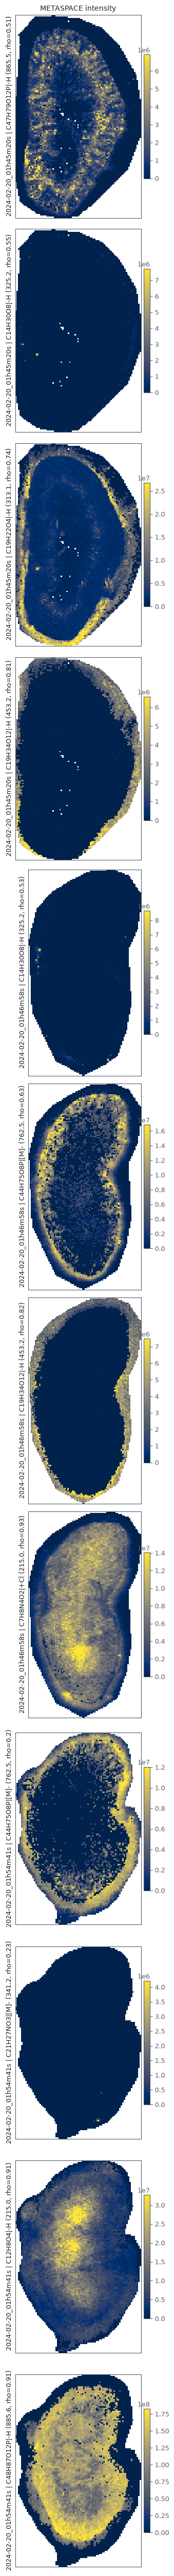

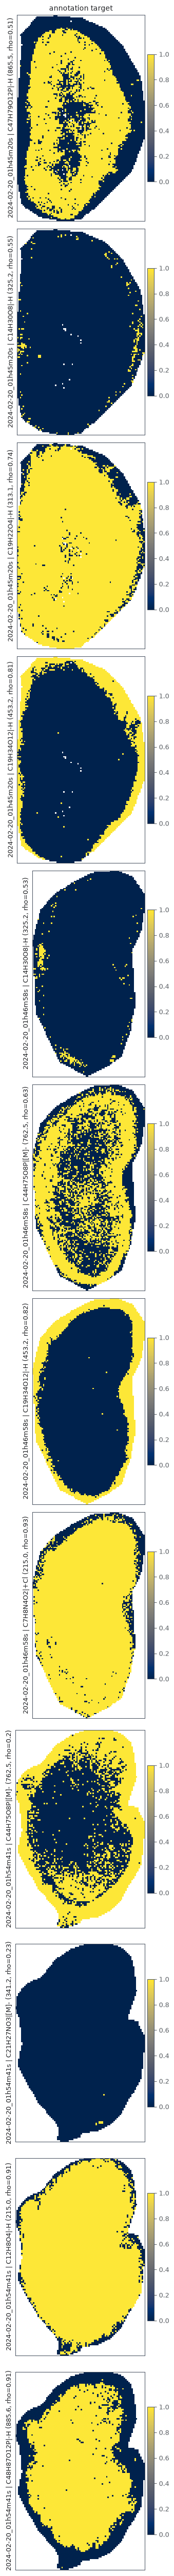

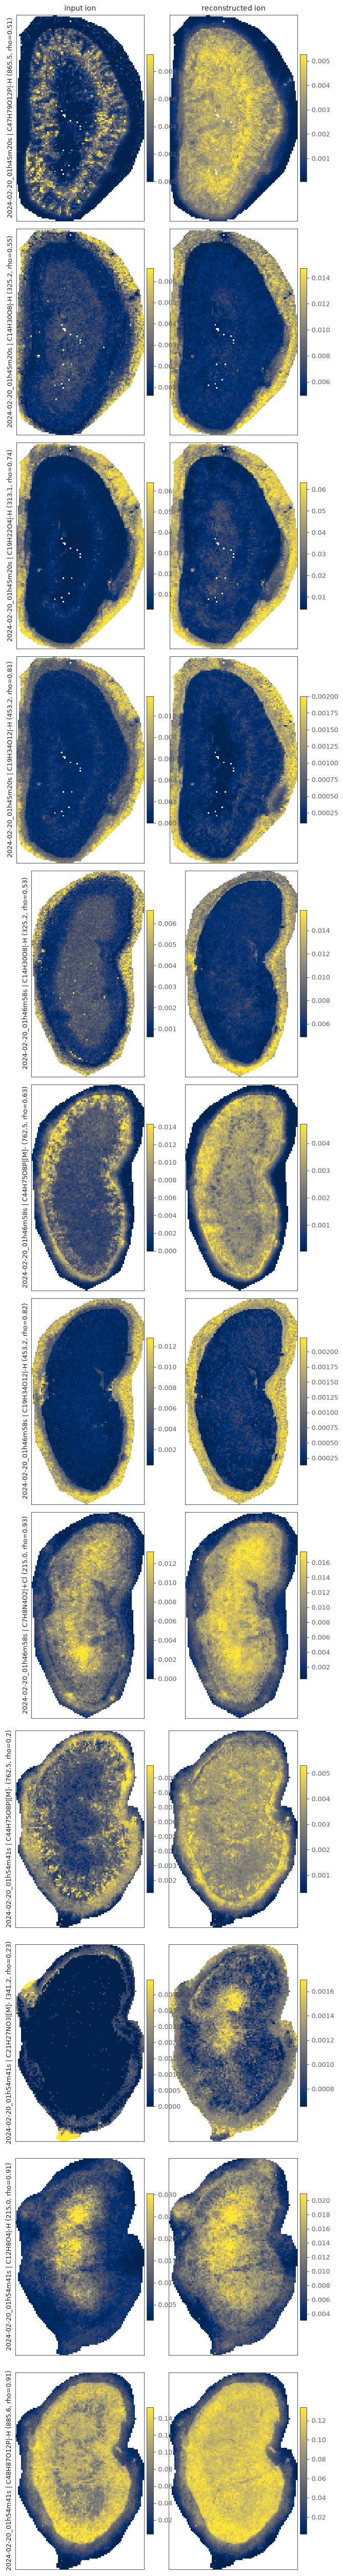

In [8]:
own = agreement[agreement.model_id == metadata['representative_model']]
ranked = own.sort_values('input_output_spearman')
chosen = pd.concat([frame.head(2) for _, frame in ranked.groupby('dataset_id')] + [frame.tail(2) for _, frame in ranked.groupby('dataset_id')])
panel = ion_pixels.merge(chosen[['ion_index', 'input_output_spearman']], on='ion_index')
panel['panel'] = panel.dataset_id + ' | ' + panel.class_name + ' (' + panel.mz.round(1).astype(str) + ', rho=' + panel.input_output_spearman.round(2).astype(str) + ')'
rows = list(dict.fromkeys(panel.sort_values(['dataset_id', 'input_output_spearman']).panel))
for name in ('metaspace', 'target'):
    figures.image_panels(panel, value_columns=[name], column_titles=['METASPACE intensity' if name == 'metaspace' else 'annotation target'], datasets=rows, row_column='panel', shared_scale='panel', positive_columns=[name], cmap=theme.image_colormap, theme=theme)
    plt.show()
figures.image_panels(panel, value_columns=['input', 'output'], column_titles=['input ion', 'reconstructed ion'], datasets=rows, row_column='panel', shared_scale='panel', cmap=theme.image_colormap, theme=theme);

### Remarks

- Best preserved: C7H8N4O2|+Cl and C12H8O4|-H (215.0 m/z) and C48H87O12P|-H (885.6), $\rho_s$ 0.91-0.93. Worst: C44H75O8P|[M]- (762.5, 0.20) and C21H27NO3|[M]- (341.2, 0.23), the latter over-reconstructed (intensity ratio 3.2).

### Notes

## Results / Summary

### LLM

- **Observed:** reconstructed images are correct for strong peaks (r about 0.9 for peaks above 10 % of the base peak) and lose shape for weak peaks; half of all peak channels have r < 0.5 and about a fifth are anti-correlated.
- **Observed:** a reconstructed channel keeps about a third of its intensity; summed ion images (three bins) keep 76-90 %.
- **Interpretation:** the whole-image mass composition is right (`part_1_04`), but single m/z images of weak ions are not reliable after reconstruction; this is the image-level consequence of the envelope-like peaks in `part_1_03`.

### Person